In [ ]:
import torch
from torch import nn, Tensor, no_grad, save, load
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import cv2 as cv

import os
import pandas as pd
import numpy as np
import time
from tqdm import tqdm

from typing import Callable, List, Tuple
from collections import OrderedDict

PREPROCESSED_PATH = './data/preprocessed/'
os.makedirs(PREPROCESSED_PATH, exist_ok=True)
IMG_PATH = './data/images/'
os.makedirs(IMG_PATH, exist_ok=True)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

c:\Users\Rafael\Documents\Workspaces\VisComp-Workspace\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Rafael\Documents\Workspaces\VisComp-Workspace\env\lib\site-packages\torch\hub.py:768: FutureWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  return _legacy_zip_load(cached_file, model_dir, map_location, weights_only)


cuda


In [2]:
df = pd.read_csv("./raw_data/cleaned_dataset.csv")
df = df[(~df["Color"].isna()) & (~df["Color"].isin(["Gold", "Silver"]))]

def filter_existing_files(df, path):    
    return df[df["file_name"].apply(lambda file: os.path.exists(os.path.join(path, file)))]

df = filter_existing_files(df, PREPROCESSED_PATH)
df.shape

(38767, 4)

In [3]:
class ClothesDataset(Dataset):
    def __init__(self, 
            df:pd.DataFrame, 
            label_column: str,
            labels:List[str],
            transform:Callable[[np.ndarray], Tensor]=transforms.ToTensor(), 
            path_images:str="./data",
            filename_column: str='file_name', 
        ) -> None:
        if label_column not in df.columns:
            raise ValueError(f"label column '{label_column}' not found in DataFrame")      
        self.path_files = path_images
        self.label_column = label_column
        self.filename_column = filename_column
        self.labels = labels
        self.df = df.dropna(subset=[label_column])  # remove linhas sem categoria
        self.transform = transform
        
        self.parse_label = {}
        self.parse_label = {label: idx for idx, label in enumerate(labels)}

    def __len__(self) -> int:
        return len(self.df)
    
    def num_labels(self) -> int:
        return len(self.labels)
    
    def true_labels(self, indexed:bool=False) -> List[str]:
        if indexed:
            return self.df[self.label_column].apply(lambda x: self.parse_label[x]).tolist()
        return self.df[self.label_column].tolist()

    def __getitem__(self, idx:int) -> Tuple[Tensor, int]:
        row = self.df.iloc[idx]
        
        image_path = os.path.join(self.path_files, row[self.filename_column])
        if not os.path.isfile(image_path):
            raise FileNotFoundError(f"Image file '{image_path}' not found")
        
        image = cv.cvtColor(cv.imread(image_path), cv.COLOR_BGR2RGB)
        image = self.transform(image)
        label = self.parse_label[row[self.label_column]]

        return image, label

In [4]:
image_size = (512, 512)

norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Resize(image_size),
  transforms.Normalize(norm_mean, norm_std),
])

label_column = "Color"
labels = df[label_column].dropna().sort_values().unique().tolist()  
labels    

['Beige',
 'Black',
 'Blue',
 'Brown',
 'Green',
 'Grey',
 'Multicolor',
 'Orange',
 'Pink',
 'Purple',
 'Red',
 'White',
 'Yellow']

In [5]:
df_train = df.sample(frac=0.7, random_state=42)
df_test = df.drop(df_train.index)

train_dataset = ClothesDataset(df, label_column, labels, transform=transform, path_images=PREPROCESSED_PATH)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = ClothesDataset(df_test, label_column, labels, transform=transform, path_images=PREPROCESSED_PATH)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [6]:
df_train.shape

(27137, 4)

In [ ]:
class Net(nn.Module):
    def __init__(self, img_size:Tuple[int, int], num_labels:int):
        super(Net, self).__init__()
        self.w, self.h = img_size
        self.num_labels = num_labels
        
        self.net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.n_features = self.net.fc.in_features 
        self.net.fc = nn.Identity() 

        self.net.fc_color = nn.Sequential(OrderedDict([
            ('linear', nn.Linear(self.n_features, self.n_features)),
            ('relu1', nn.ReLU()),
            ('final', nn.Linear(self.n_features, num_labels))
        ]))
    
        for param in self.net.parameters():
            param.requires_grad = False  
        for param in self.net.fc_color.parameters():
            param.requires_grad = True
            
    def forward(self, x: Tensor) -> Tuple[Tensor]:
        features = self.net(x)
        return self.net.fc_color(features)


model = Net(image_size, train_dataset.num_labels())
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
epochs = 10

running_losses = []

total_batches = epochs * len(train_dataloader)
progress_bar = tqdm(total=total_batches, desc="Training Progress", position=0, bar_format='{l_bar}{bar:20}{r_bar}')

start_time = time.time()
model.train()
for epoch in range(epochs):
    epoch_running_loss = 0
    for i, batch in enumerate(train_dataloader):
        imgs, labels = batch
        optimizer.zero_grad()
        
        output = model(imgs.to(device))
        
        loss = criterion(output, labels.to(device))
        loss.backward()
        optimizer.step()
        
        epoch_running_loss += loss.item()
        
        progress_bar.update(1)
        progress_bar.set_postfix(epoch=epoch+1, batch=i+1, loss=round(loss.item()/len(batch), 2))
        
    running_losses.append(epoch_running_loss)
progress_bar.close()

In [ ]:
if not os.path.exists(f"./models"):
    os.makedirs(f"./models")

save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "time": time.time() - start_time,
        "running_losses": running_losses
    }, 
    os.path.join(f"./models/model_{label_column}.pt")
)

In [ ]:
correct = 0
pred_labels = []

total_batches = len(test_dataloader)
progress_bar = tqdm(total=total_batches, desc="Test Progress", position=0, bar_format='{l_bar}{bar:20}{r_bar}')

start_time = time.time()
model.eval()
with no_grad():
    for i, batch in enumerate(test_dataloader):
        imgs, labels = batch
        prediction = model(imgs.to(device))
            
        _, prediction = torch.max(prediction.data, 1)
        correct += (prediction == labels.to(device)).sum().item()
        pred_labels += prediction.cpu().tolist()
        
        progress_bar.update(1)
        progress_bar.set_postfix(batch=i+1, accuracy=round(correct/len(pred_labels), 2))
    progress_bar.close()

Test Progress: 100%|████████████████████| 91/91 [16:39<00:00, 10.99s/it, accuracy=0.82, batch=91]


In [ ]:
df_train.shape


NameError: name 'df_train' is not defined

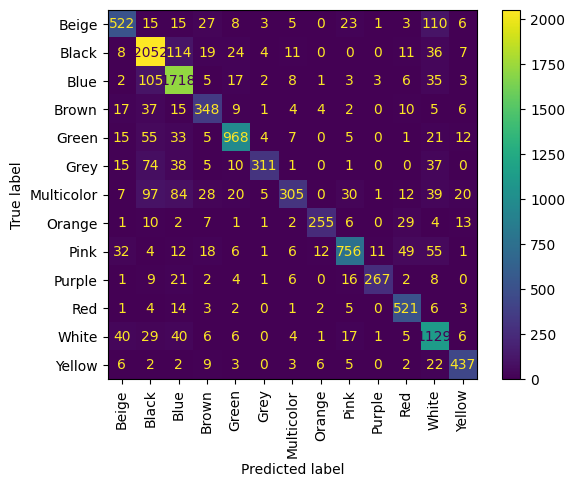

In [ ]:
matrix = confusion_matrix(test_dataset.true_labels(True), pred_labels)
ConfusionMatrixDisplay(matrix, display_labels=test_dataset.labels).plot(xticks_rotation="vertical")
